In [82]:
import pandas as pd

In [4]:
# import pandas library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df= pd.read_csv('heart_disease_uci(1).csv')

In [6]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
df.shape

(920, 16)

In [9]:
df.duplicated().sum()

0

In [10]:
# data cleaning 


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
915    False
916    False
917    False
918    False
919    False
Length: 920, dtype: bool

In [13]:
df.dtypes

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

In [14]:
# we are doing the process of the imputation that is the data cleaning as welll as the error correction

In [15]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

# data Cleaning

In [28]:
# now we are going to perform the step of imputation where what we will do is we will replace the null values with the mean and mode so lets start


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [32]:
#now in case of this the Use Mean When:
#The column is numerical and continuous (e.g., blood pressure, cholesterol).
#The data is approximately normally distributed (not heavily skewed).
# and we use the mode when the columns are categorical The column is categorical (even if stored as numbers).
#It represents discrete choices or categories rather than continuous values.

In [34]:
df.head(2)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2


In [36]:
mean_columns = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
#median_columns = []  # You can add columns here if median imputation is required
mode_columns = ['fbs', 'restecg', 'exang', 'slope', 'thal']

# Impute using mean for numeric columns
for col in mean_columns:
    if col in df.columns:
        df[col].fillna(df[col].mean(), inplace=True)

# Impute using mode for categorical columns
for col in mode_columns:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_22652\2616037149.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_22652\2616037149.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [38]:
print("Data after imputing missing values:")
print(df.isnull().sum())  # To verify no missing values remain

Data after imputing missing values:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


# Data Integration

In [42]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [44]:
df1 = df[['thalch','trestbps','oldpeak']]
df2= df [['exang','slope','num']]

In [46]:
merged_df = pd.concat([df1,df2],axis=1)

In [48]:
merged_df

,thalch,trestbps,oldpeak,exang,slope,num
0,150.000000,145.000000,2.300000,False,downsloping,0
1,108.000000,160.000000,1.500000,True,flat,2
2,129.000000,120.000000,2.600000,True,flat,1
3,187.000000,130.000000,3.500000,False,downsloping,0
4,172.000000,130.000000,1.400000,False,upsloping,0
...,...,...,...,...,...,...
915,154.000000,127.000000,0.000000,False,flat,1
916,137.545665,132.132404,0.878788,False,flat,0
917,100.000000,122.000000,0.000000,False,flat,2
918,137.545665,132.132404,0.878788,False,flat,0


# Error Correction

In [57]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 2.5 * IQR
    # Remove outliers (returns a Series with only valid values)
    column = column[(column >= Q1 - threshold) & (column <= Q3 + threshold)]
    return column.fillna(column.median())  # Replace NaN with the median of the column

col_name = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in col_name:
    df[col] = remove_outliers(df[col])

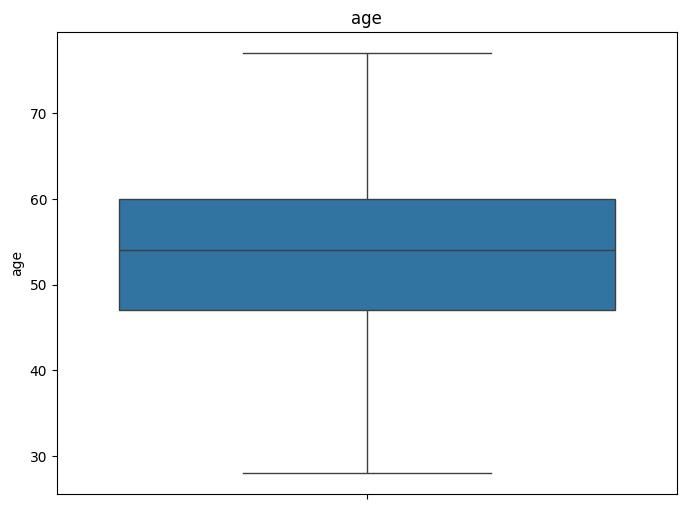

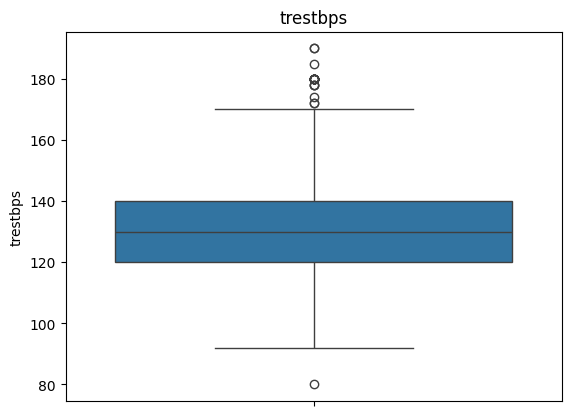

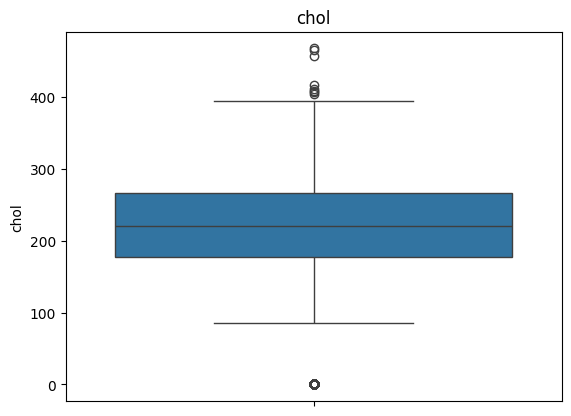

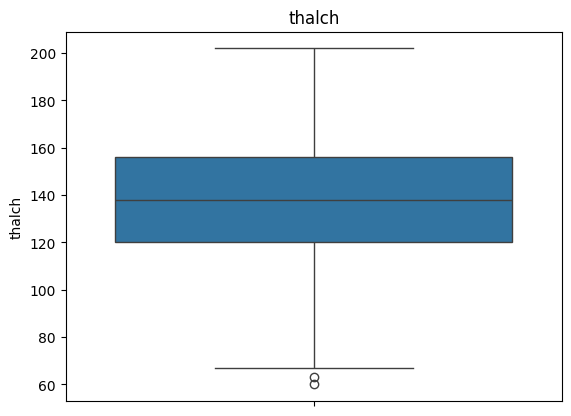

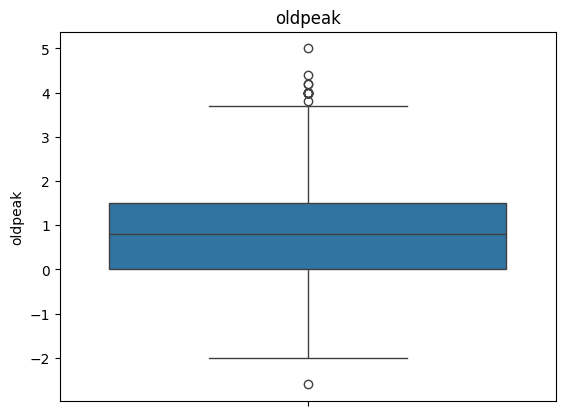

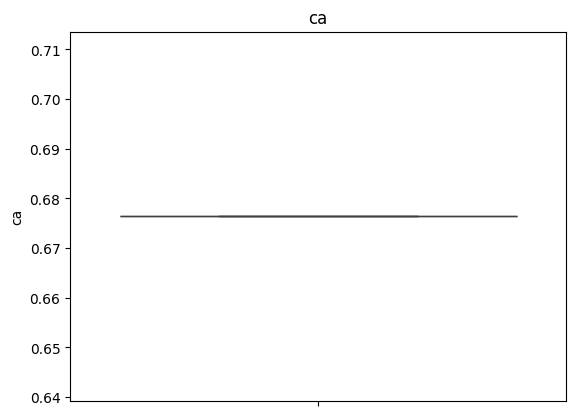

In [60]:
plt.figure(figsize=(8, 6))  # Adjust the figure size if needed

for col in col_name:
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()

# Model Training

Correlation with the Target:
id          0.273552
age         0.339596
trestbps    0.117097
chol       -0.231596
thalch     -0.351055
oldpeak     0.415495
ca               NaN
Name: num, dtype: float64



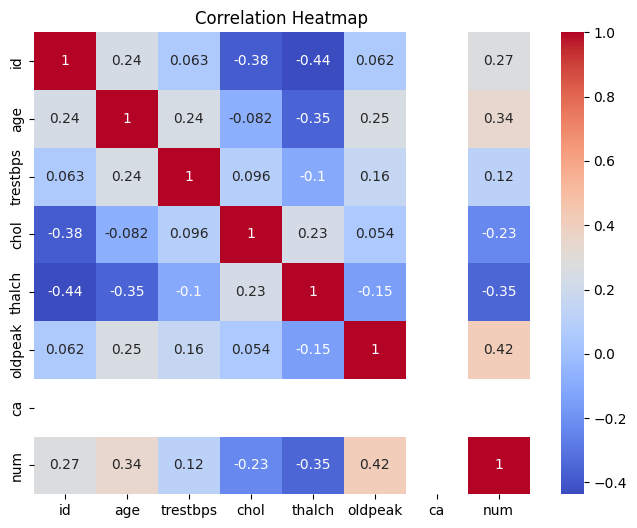

In [69]:
# Convert 'sex' column to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

# Before calculating correlations, select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Now calculate correlations on the numeric DataFrame
correlations = numeric_df.corr()['num'].drop('num')

# Print correlations
print("Correlation with the Target:")
print(correlations)
print()

# Plot correlation heatmap using the numeric DataFrame
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [71]:
df1 = df.copy()

In [73]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Initialize LabelEncoder and StandardScaler
label_encoder = LabelEncoder()
scaler = StandardScaler()

# List of categorical columns for label encoding
categorical_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']

# Apply Label Encoding to categorical columns
for col in categorical_cols:
    if col in df1.columns:
        df1[col] = label_encoder.fit_transform(df1[col])

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
# Standardize numeric columns
df1[numeric_cols] = scaler.fit_transform(df1[numeric_cols])

# Final DataFrame
print("Processed DataFrame:")
print(df1)


Processed DataFrame:
      id       age  sex  dataset  cp  trestbps      chol    fbs  restecg  \
0      1  1.007386    1        0   3  0.756997  0.336591   True        0   
1      2  1.432034    1        0   0  1.624745  0.835764  False        0   
2      3  1.432034    1        0   0 -0.689250  0.298918  False        0   
3      4 -1.752828    1        0   2 -0.110751  0.496703  False        1   
4      5 -1.328180    0        0   1 -0.110751  0.063459  False        0   
..   ...       ...  ...      ...  ..       ...       ...    ...      ...   
915  916  0.051927    0        3   0 -0.284301  1.278427   True        2   
916  917  0.901224    1        3   3  0.012608 -0.548734  False        2   
917  918  0.158089    1        3   0 -0.573550  0.242408   True        2   
918  919  0.476575    1        3   0  0.012608  1.768181   True        0   
919  920  0.901224    1        3   1 -0.689250  0.534377  False        0   

       thalch  exang   oldpeak  slope            ca  thal  num  
0

In [79]:
# In some of the features, there is space will will create problem later on.
# So we rename those attributes to handle problems in the future.
df['thal'].replace({'fixed defect':'fixed_defect' , 'reversable defect': 'reversable_defect' }, inplace =True)
df['cp'].replace({'typical angina':'typical_angina', 'atypical angina': 'atypical_angina' }, inplace =True)
df['restecg'].replace({'normal': 'normal' , 'st-t abnormality': 'ST-T_wave_abnormality' , 'lv hypertrophy': 'left_ventricular_hypertrophy' }, inplace =True)

# Genrating New Dataset with Less Columns Which Are Necessary .
data_1 = df[['age','sex','cp','dataset', 'trestbps', 'chol', 'fbs','restecg' , 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']].copy()
# Some Changes in Target Variable | Only Two Categories (0,1) . 0 for No-Disease , 1 for Disease
data_1['target'] = ((df['num'] > 0)*1).copy()
# Encoding Sex
data_1['sex'] = (df['sex'] == 'Male')*1
# Encoding Fbs and exang
data_1['fbs'] = (df['fbs'])*1
data_1['exang'] = (df['exang'])*1
# Renaming COlumns Names.
data_1.columns = ['age', 'sex', 'chest_pain_type','country' ,'resting_blood_pressure',
              'cholesterol', 'fasting_blood_sugar','Restecg',
              'max_heart_rate_achieved', 'exercise_induced_angina',
              'st_depression', 'st_slope_type', 'num_major_vessels',
              'thalassemia_type', 'target']
# Load Data Sample
data_1.head()

C:\Users\shubh\AppData\Local\Temp\ipykernel_22652\589518934.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['thal'].replace({'fixed defect':'fixed_defect' , 'reversable defect': 'reversable_defect' }, inplace =True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_22652\589518934.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

,age,sex,chest_pain_type,country,resting_blood_pressure,cholesterol,fasting_blood_sugar,Restecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope_type,num_major_vessels,thalassemia_type,target
0,63,1,typical_angina,Cleveland,145.0,233.0,1,left_ventricular_hypertrophy,150.0,0,2.3,downsloping,NaN,fixed_defect,0
1,67,1,asymptomatic,Cleveland,160.0,286.0,0,left_ventricular_hypertrophy,108.0,1,1.5,flat,NaN,normal,1
2,67,1,asymptomatic,Cleveland,120.0,229.0,0,left_ventricular_hypertrophy,129.0,1,2.6,flat,NaN,reversable_defect,1
3,37,1,non-anginal,Cleveland,130.0,250.0,0,normal,187.0,0,3.5,downsloping,NaN,normal,0
4,41,0,atypical_angina,Cleveland,130.0,204.0,0,left_ventricular_hypertrophy,172.0,0,1.4,upsloping,NaN,normal,0


In [81]:
X = data_1.drop('target',axis=1)
y = data_1['target']

# Encode X using data seperate label encoder for all categorical columns
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object'  or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [83]:
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score

# For classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score , mean_absolute_error  , mean_squared_error , r2_score


In [85]:
models = [
    ('LogisticRegression', LogisticRegression(random_state=42)),
    ('SVM', SVC(random_state=42, probability=True)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42)),

    ('KNeighborsClassifier', KNeighborsClassifier()),

]

In [87]:
# Impute missing values using SimpleImputer before splitting
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Or 'median', 'most_frequent'
X = imputer.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) # Split data after imputation

In [89]:
model_scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted for imbalanced data
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    # Append metrics
    model_scores.append((name, accuracy, f1, precision, recall, roc_auc))

    # Print results
    print(f"{name} Accuracy: {accuracy:.2f}")
    print(f"{name} F1 Score: {f1:.2f}")
    print(f"{name} Precision: {precision:.2f}")
    print(f"{name} Recall: {recall:.2f}")
    if roc_auc is not None:
        print(f"{name} ROC AUC: {roc_auc:.2f}")
    print("-" * 50)

C:\Users\shubh\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 0.80
LogisticRegression F1 Score: 0.80
LogisticRegression Precision: 0.80
LogisticRegression Recall: 0.80
LogisticRegression ROC AUC: 0.88
--------------------------------------------------
SVM Accuracy: 0.71
SVM F1 Score: 0.71
SVM Precision: 0.72
SVM Recall: 0.71
SVM ROC AUC: 0.82
--------------------------------------------------
DecisionTreeClassifier Accuracy: 0.80
DecisionTreeClassifier F1 Score: 0.80
DecisionTreeClassifier Precision: 0.80
DecisionTreeClassifier Recall: 0.80
DecisionTreeClassifier ROC AUC: 0.80
--------------------------------------------------
KNeighborsClassifier Accuracy: 0.67
KNeighborsClassifier F1 Score: 0.67
KNeighborsClassifier Precision: 0.67
KNeighborsClassifier Recall: 0.67
KNeighborsClassifier ROC AUC: 0.74
--------------------------------------------------
